# Analyse OOD par autoencoder

Ce notebook exploite les sorties de `scripts/evaluate_autoencoder.py` pour analyser les erreurs de reconstruction du modèle autoencoder et verifier le comportement sur les images hors-domaine de `data/ood/`.

Le seuil OOD utilise ici le percentile 95 des erreurs de reconstruction sur le split validation.

In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RUN_NAME = "conv_autoencoder_latent-256_lr-0.0001_final"
EVAL_DIR = PROJECT_ROOT / "reports" / "ood" / RUN_NAME / "evaluation"
ERRORS_PATH = EVAL_DIR / "reconstruction_errors.csv"
THRESHOLD_PATH = EVAL_DIR / "ood_threshold.json"

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation dir: {EVAL_DIR}")
print(f"Errors CSV exists: {ERRORS_PATH.exists()}")
print(f"Threshold JSON exists: {THRESHOLD_PATH.exists()}")

Project root: /Users/hugo/Dev/CNN_Hopital
Evaluation dir: /Users/hugo/Dev/CNN_Hopital/reports/ood/conv_autoencoder_latent-256_lr-0.0001_final/evaluation
Errors CSV exists: True
Threshold JSON exists: True


In [11]:
errors_df = pd.read_csv(ERRORS_PATH)

with open(THRESHOLD_PATH, "r", encoding="utf-8") as f:
    threshold_data = json.load(f)

threshold = threshold_data["threshold"]

pd.set_option("display.max_colwidth", None)

display(Markdown(f"**Seuil OOD P{threshold_data['threshold_percentile']:.0f} validation : `{threshold:.8f}`**"))
display(pd.DataFrame([threshold_data]).T.rename(columns={0: "value"}))

**Seuil OOD P95 validation : `0.02828478`**

,value
method,validation_reconstruction_error_percentile
threshold_percentile,95.0
threshold,0.028285
model_checkpoint,/Users/hugo/Dev/CNN_Hopital/models/conv_autoencoder_latent-256_lr-0.0001_final_best.pt
latent_dim,256
img_size,224
train_error_mean,0.00571
train_error_std,0.002817
val_error_mean,0.01391
val_error_std,0.008759


In [12]:
summary_by_split = (
    errors_df
    .groupby("split")["reconstruction_error"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_index()
)

display(summary_by_split)

rejection_summary = (
    errors_df
    .groupby("split")["is_above_threshold"]
    .agg(total="count", rejected="sum")
)
rejection_summary["rejection_rate"] = rejection_summary["rejected"] / rejection_summary["total"]

display(rejection_summary)

,count,mean,std,min,max
split,,,,,
ood,5,0.023257,0.011254,0.004575,0.032216
test,65,0.013906,0.008480,0.001855,0.050230
train,301,0.005710,0.002817,0.001613,0.025130
val,65,0.013910,0.008759,0.001530,0.041346


,total,rejected,rejection_rate
split,,,
ood,5,3,0.600000
test,65,3,0.046154
train,301,0,0.000000
val,65,4,0.061538


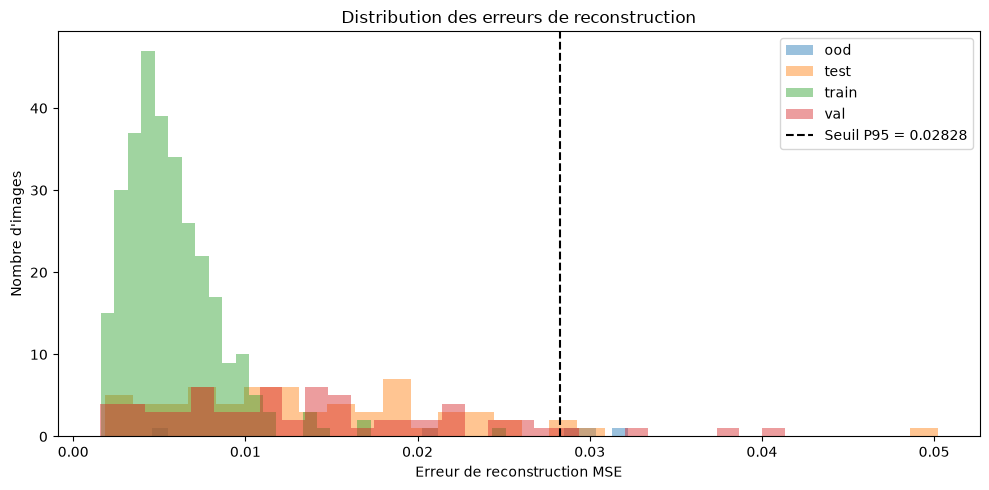

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

for split_name, split_df in errors_df.groupby("split"):
    ax.hist(
        split_df["reconstruction_error"],
        bins=30,
        alpha=0.45,
        label=split_name,
    )

ax.axvline(threshold, linestyle="--", color="black", label=f"Seuil P95 = {threshold:.5f}")
ax.set_title("Distribution des erreurs de reconstruction")
ax.set_xlabel("Erreur de reconstruction MSE")
ax.set_ylabel("Nombre d'images")
ax.legend()
plt.tight_layout()
plt.show()

## Analyse des images OOD

Les cellules suivantes affichent les chemins complets et relatifs des images hors-domaine afin de faciliter la verification des fichiers utilises pour le test.

In [14]:
def normalize_image_path(value):
    """Retourne le chemin absolu et le chemin relatif projet pour une image."""
    path = Path(value)
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    path = path.resolve()

    try:
        relative_path = path.relative_to(PROJECT_ROOT.resolve())
    except ValueError:
        relative_path = path

    return path, relative_path


ood_df = errors_df[errors_df["split"] == "ood"].copy()

if ood_df.empty:
    display(Markdown("Aucune image OOD n'a ete trouvee dans `reconstruction_errors.csv`."))
else:
    normalized_paths = ood_df["image_path"].apply(normalize_image_path)
    ood_df["absolute_image_path"] = normalized_paths.apply(lambda item: str(item[0]))
    ood_df["relative_image_path"] = normalized_paths.apply(lambda item: str(item[1]))
    ood_df["file_exists"] = ood_df["absolute_image_path"].apply(lambda value: Path(value).exists())
    ood_df["ood_decision"] = ood_df["is_above_threshold"].map({True: "REJETEE", False: "ACCEPTEE"})

    display(
        ood_df[[
            "relative_image_path",
            "absolute_image_path",
            "file_exists",
            "reconstruction_error",
            "is_above_threshold",
            "ood_decision",
        ]].sort_values("reconstruction_error", ascending=False)
    )

,relative_image_path,absolute_image_path,file_exists,reconstruction_error,is_above_threshold,ood_decision
434,data/ood/random_object.jpg,/Users/hugo/Dev/CNN_Hopital/data/ood/random_object.jpg,True,0.032216,True,REJETEE
433,data/ood/landscape.jpg,/Users/hugo/Dev/CNN_Hopital/data/ood/landscape.jpg,True,0.029869,True,REJETEE
435,data/ood/xray.jpg,/Users/hugo/Dev/CNN_Hopital/data/ood/xray.jpg,True,0.028603,True,REJETEE
431,data/ood/cat.jpg,/Users/hugo/Dev/CNN_Hopital/data/ood/cat.jpg,True,0.021025,False,ACCEPTEE
432,data/ood/healthy_skin_or_other.jpg,/Users/hugo/Dev/CNN_Hopital/data/ood/healthy_skin_or_other.jpg,True,0.004575,False,ACCEPTEE


### `data/ood/random_object.jpg`
- Chemin absolu : `/Users/hugo/Dev/CNN_Hopital/data/ood/random_object.jpg`
- Erreur de reconstruction : `0.03221628`
- Decision avec seuil P95 : **REJETEE**

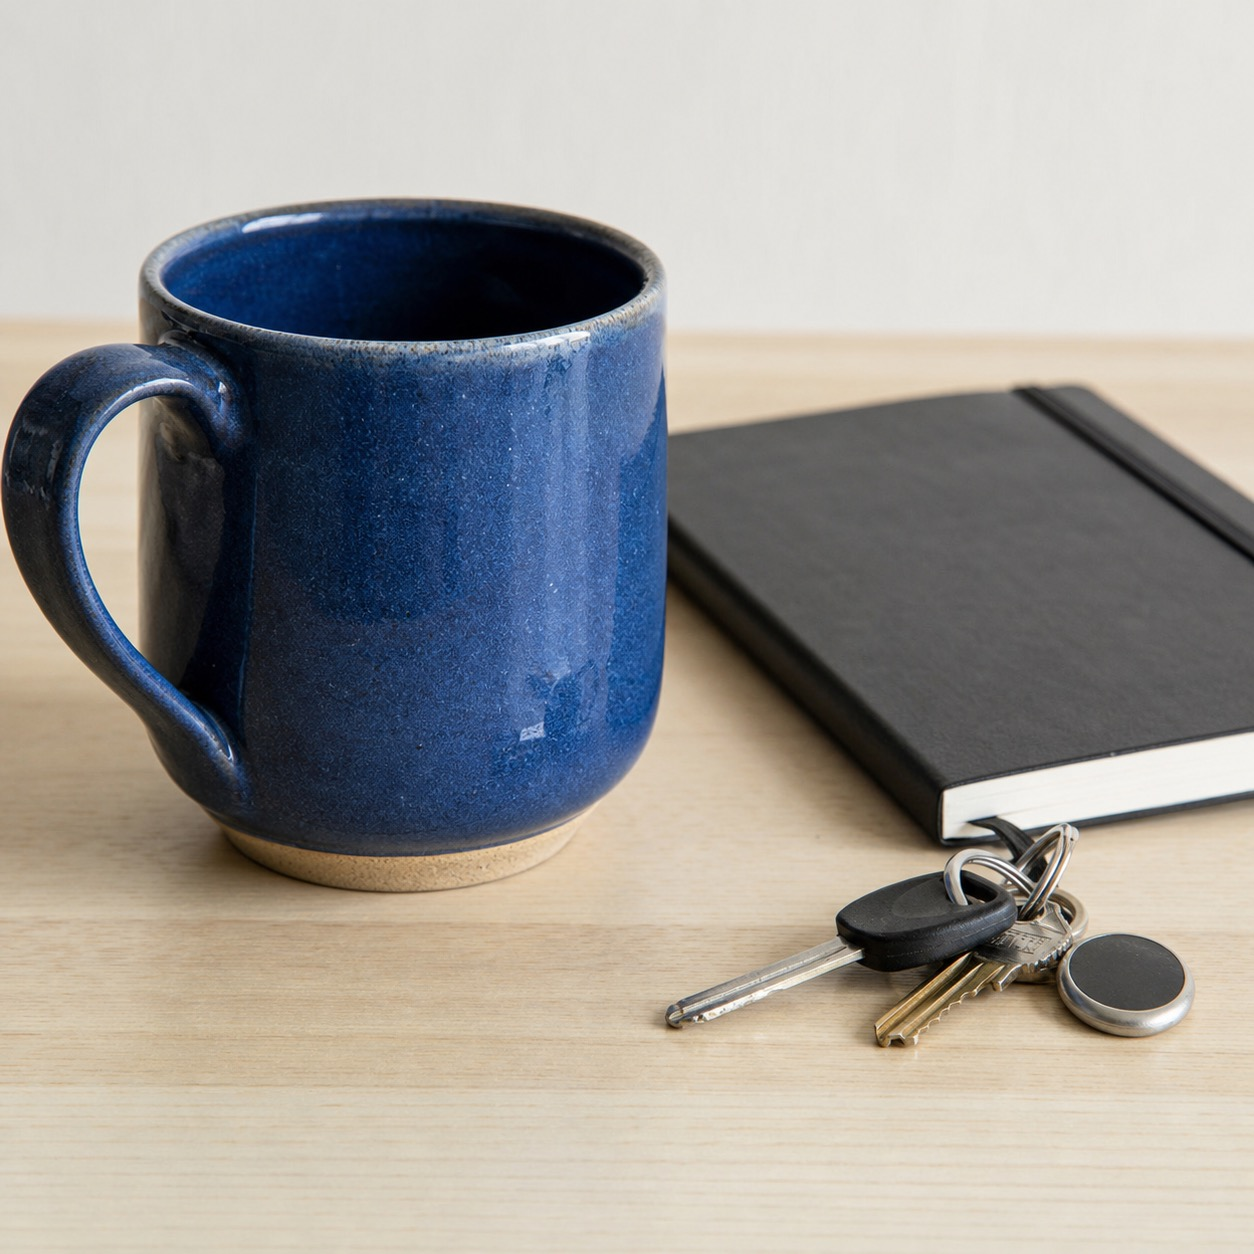

### `data/ood/landscape.jpg`
- Chemin absolu : `/Users/hugo/Dev/CNN_Hopital/data/ood/landscape.jpg`
- Erreur de reconstruction : `0.02986851`
- Decision avec seuil P95 : **REJETEE**

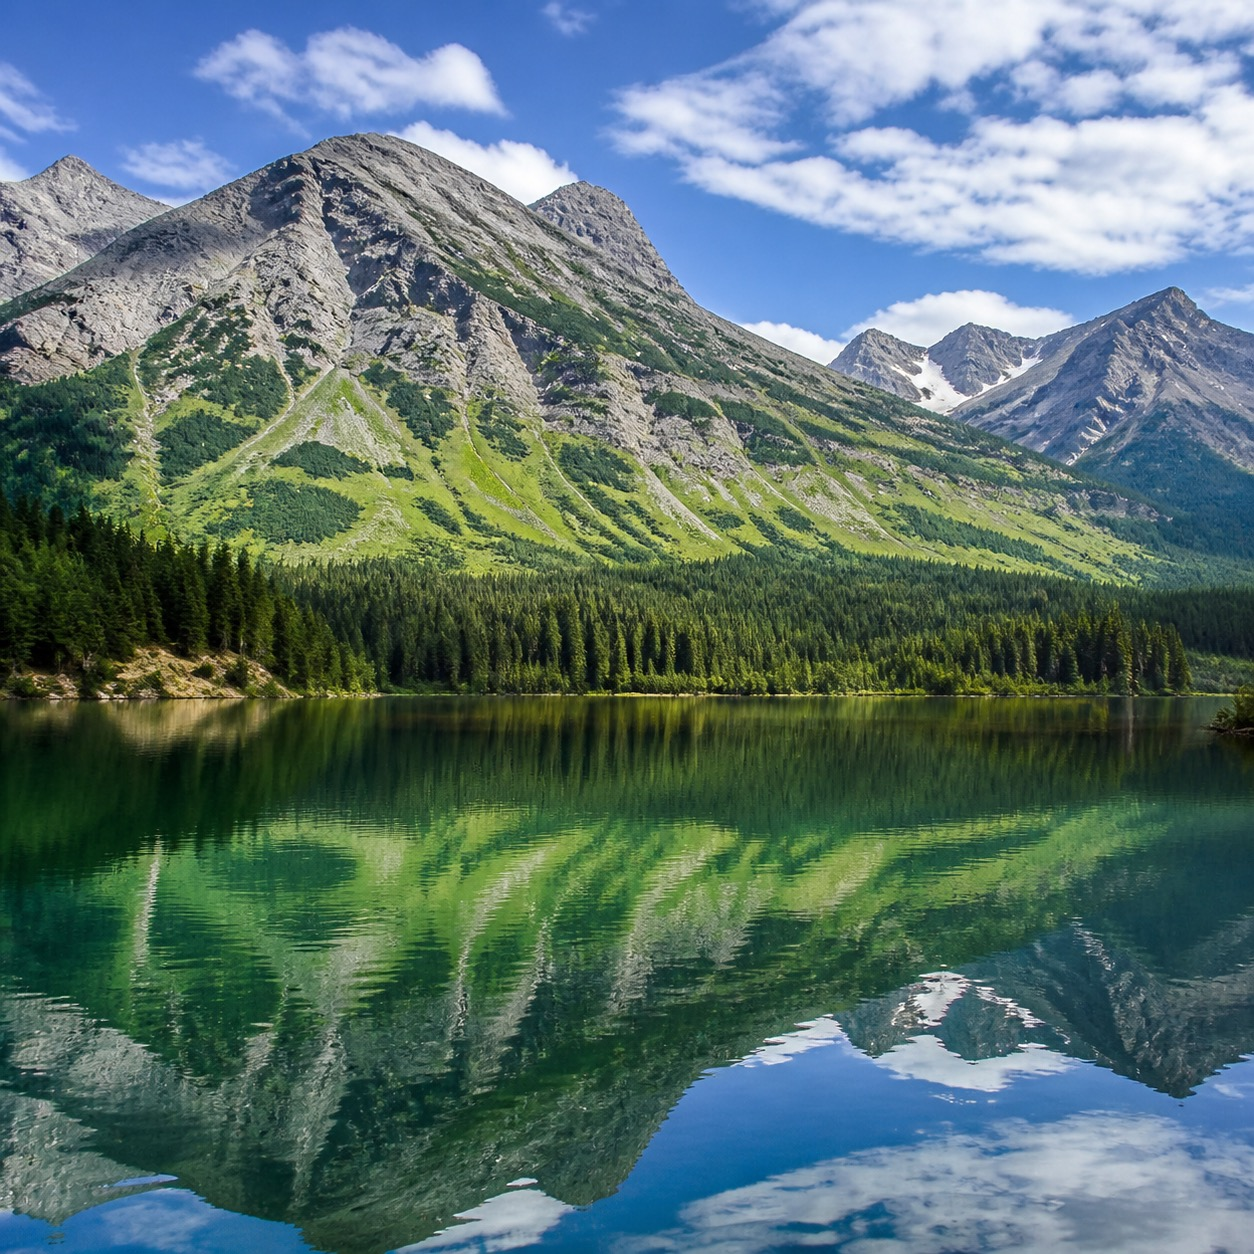

### `data/ood/xray.jpg`
- Chemin absolu : `/Users/hugo/Dev/CNN_Hopital/data/ood/xray.jpg`
- Erreur de reconstruction : `0.02860305`
- Decision avec seuil P95 : **REJETEE**

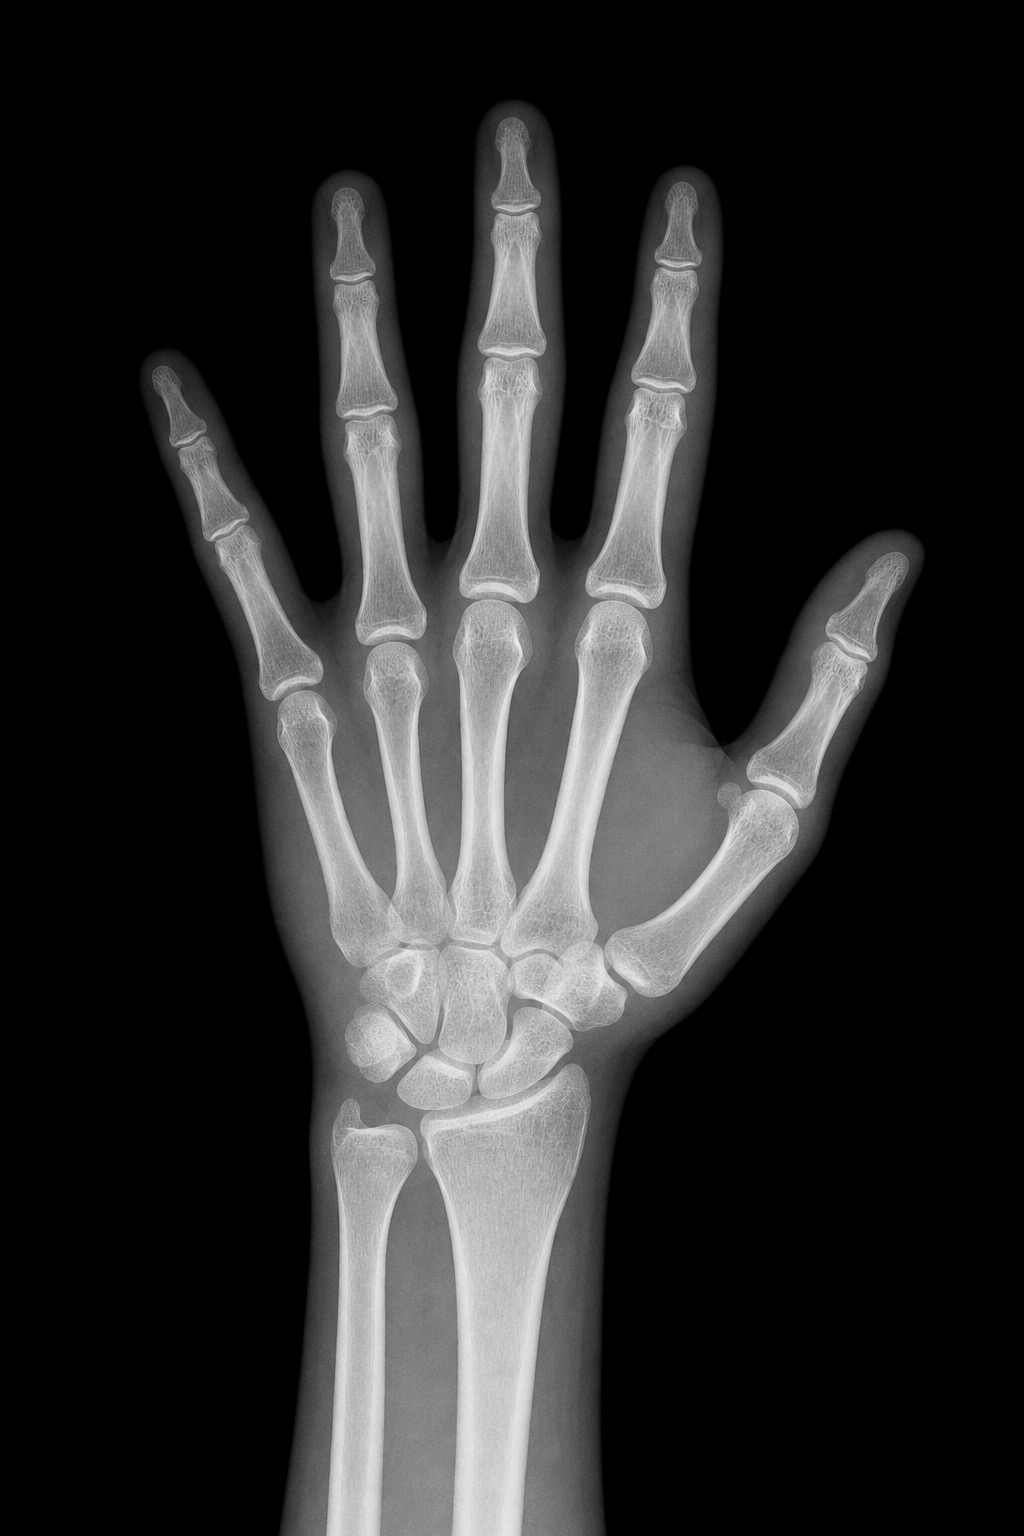

### `data/ood/cat.jpg`
- Chemin absolu : `/Users/hugo/Dev/CNN_Hopital/data/ood/cat.jpg`
- Erreur de reconstruction : `0.02102460`
- Decision avec seuil P95 : **ACCEPTEE**

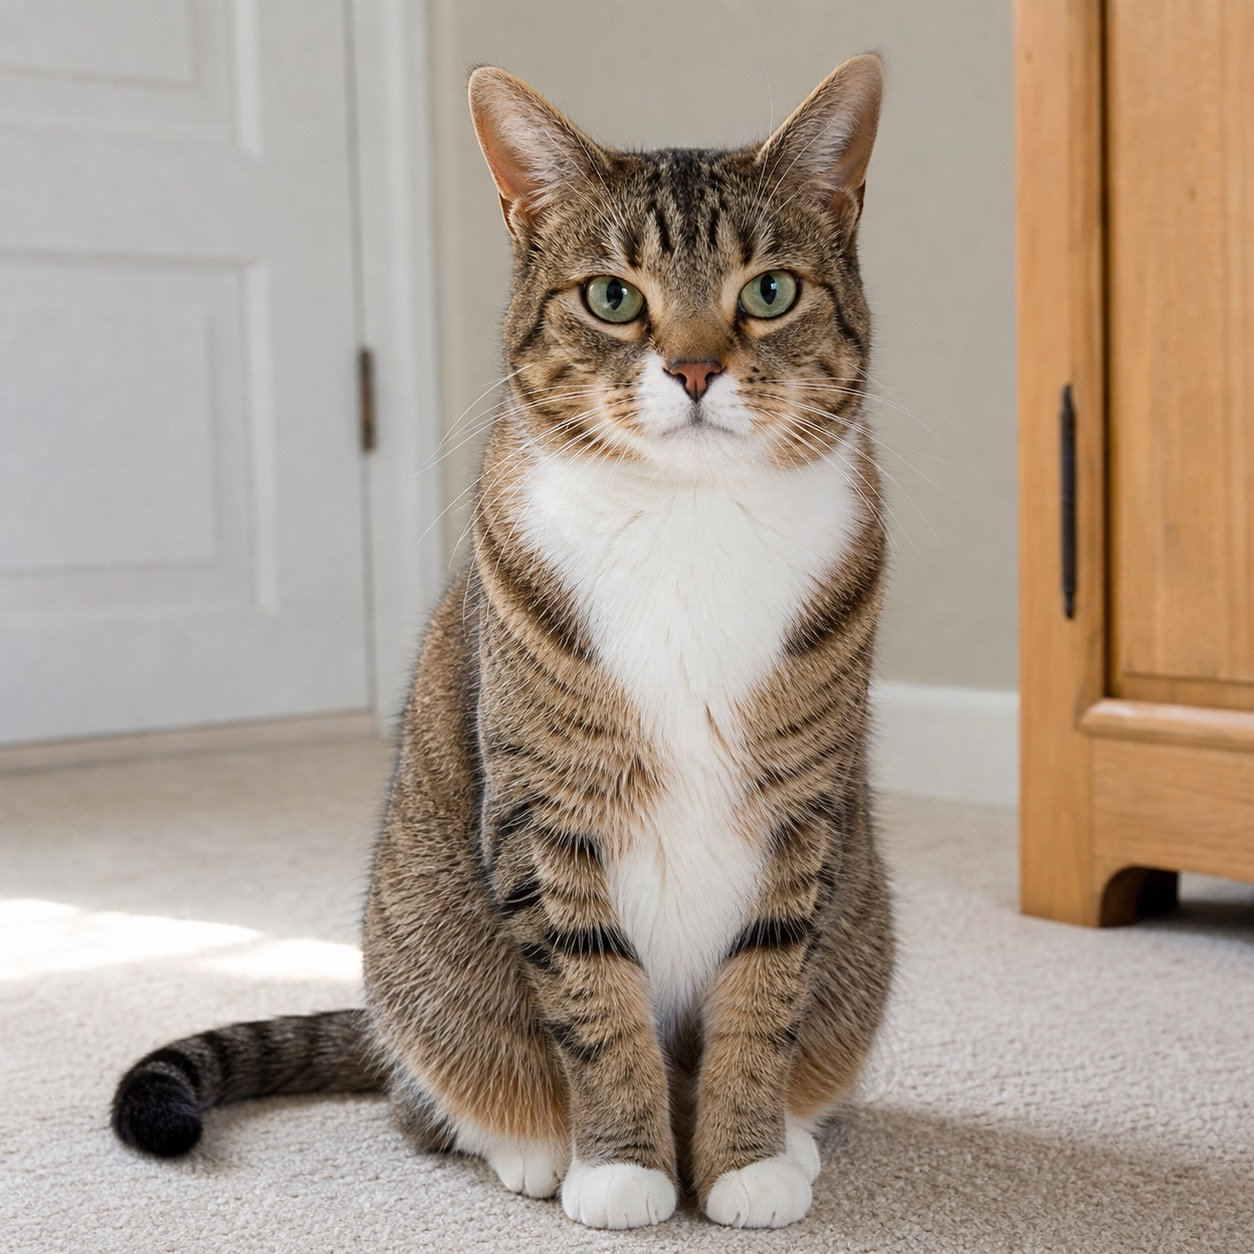

### `data/ood/healthy_skin_or_other.jpg`
- Chemin absolu : `/Users/hugo/Dev/CNN_Hopital/data/ood/healthy_skin_or_other.jpg`
- Erreur de reconstruction : `0.00457484`
- Decision avec seuil P95 : **ACCEPTEE**

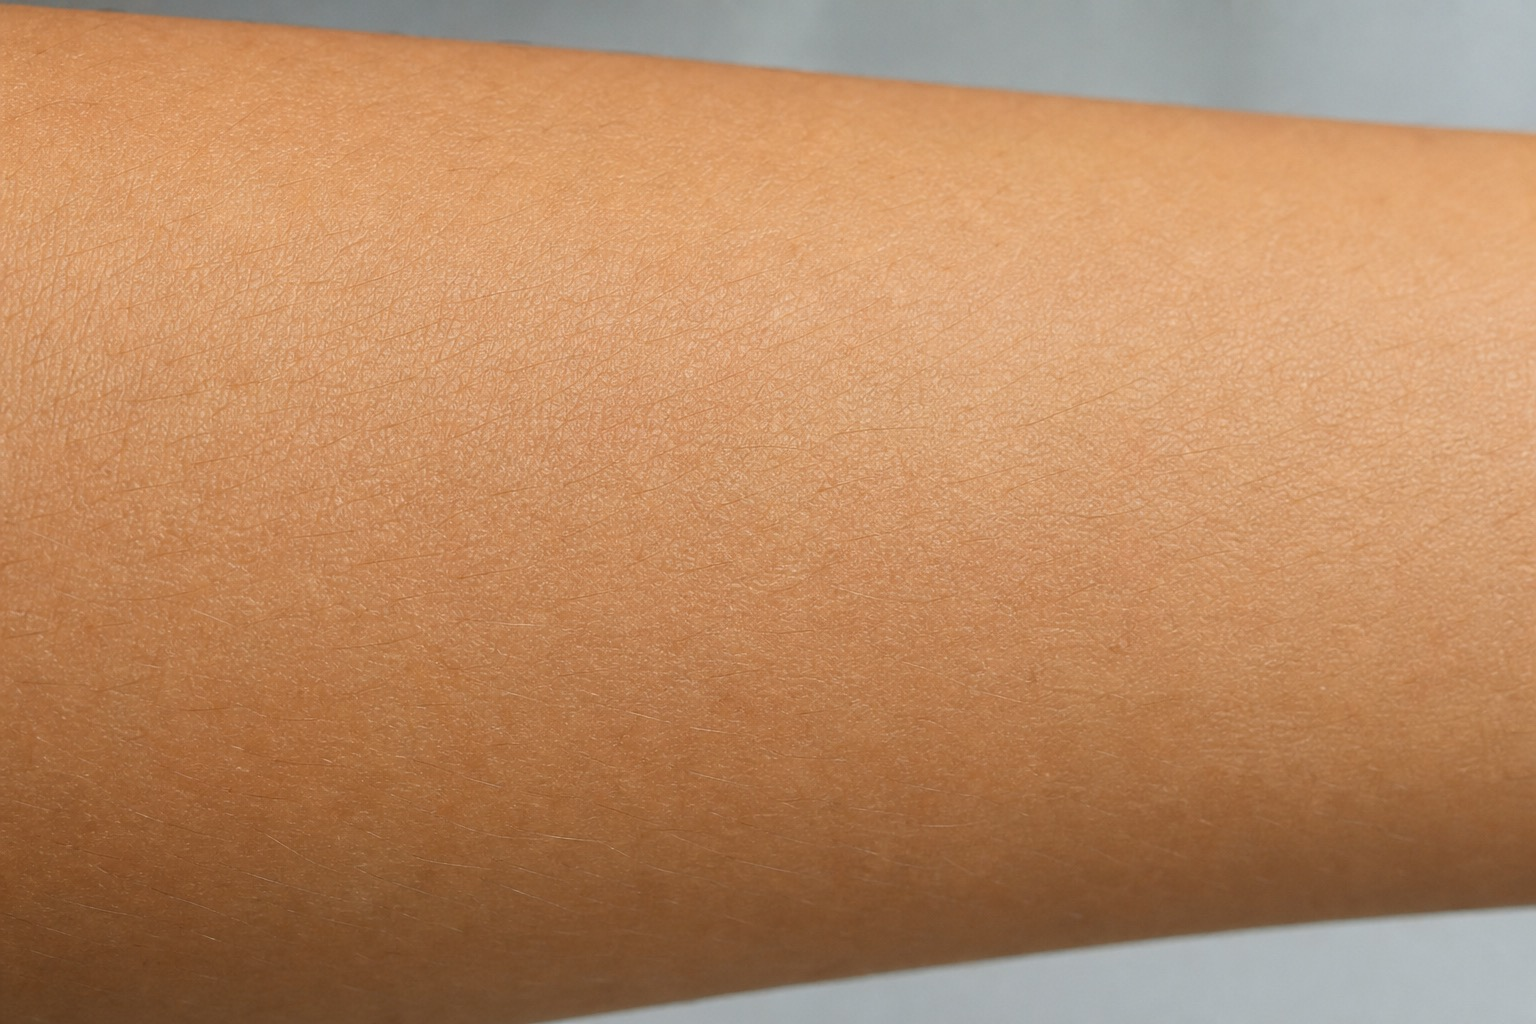

In [15]:
if not ood_df.empty:
    for _, row in ood_df.sort_values("reconstruction_error", ascending=False).iterrows():
        abs_path = Path(row["absolute_image_path"])
        rel_path = row["relative_image_path"]
        decision = row["ood_decision"]
        error = row["reconstruction_error"]

        display(Markdown(
            f"### `{rel_path}`\n"
            f"- Chemin absolu : `{abs_path}`\n"
            f"- Erreur de reconstruction : `{error:.8f}`\n"
            f"- Decision avec seuil P95 : **{decision}**"
        ))

        if abs_path.exists():
            display(Image(filename=str(abs_path), width=260))
        else:
            display(Markdown("Image introuvable sur disque."))

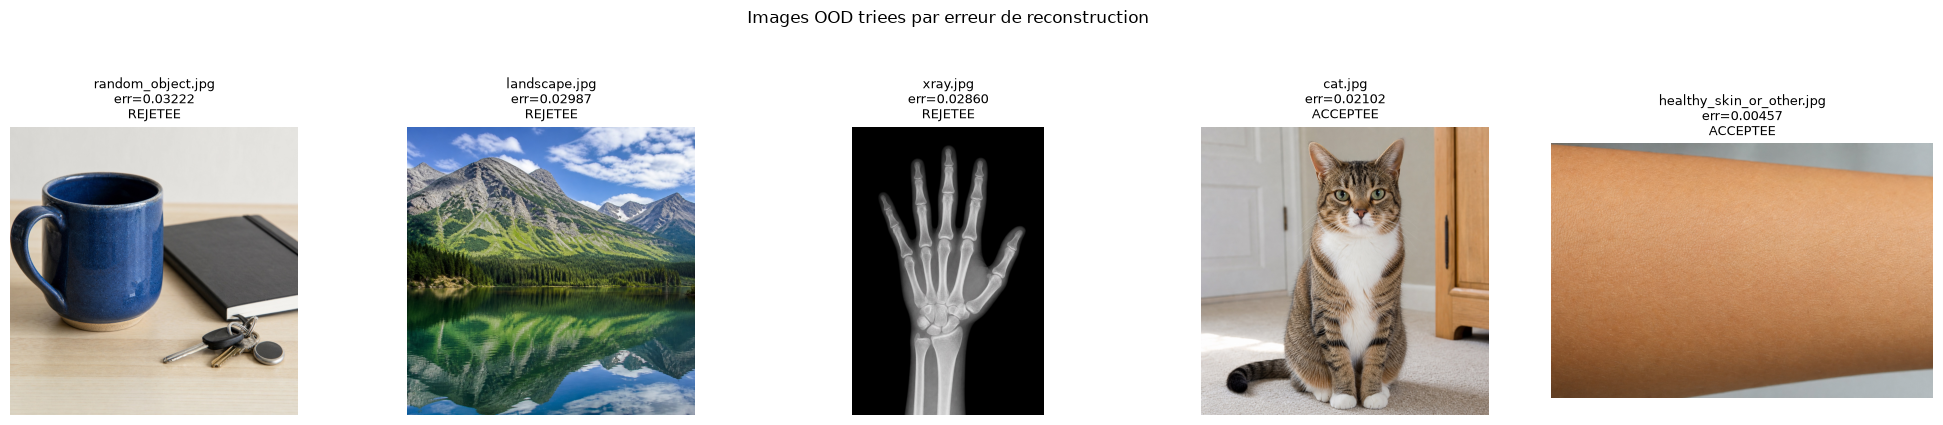

In [16]:
if not ood_df.empty:
    fig, axes = plt.subplots(1, len(ood_df), figsize=(4 * len(ood_df), 4))
    if len(ood_df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, ood_df.sort_values("reconstruction_error", ascending=False).iterrows()):
        image_path = Path(row["absolute_image_path"])
        image = plt.imread(image_path)
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"{Path(row['relative_image_path']).name}\n"
            f"err={row['reconstruction_error']:.5f}\n"
            f"{row['ood_decision']}",
            fontsize=9,
        )

    plt.suptitle("Images OOD triees par erreur de reconstruction", y=1.05)
    plt.tight_layout()
    plt.show()

## Points d'attention

- Avec le seuil P95, seules les images dont l'erreur depasse le percentile 95 validation sont rejetees.
- `healthy_skin_or_other.jpg` peut etre acceptee car elle reste visuellement proche du domaine des images cutanees, meme sans plaie.
- `cat.jpg` peut aussi etre acceptee si ses textures et couleurs restent faciles a reconstruire par l'autoencoder. Cela montre que l'erreur de reconstruction seule n'est pas toujours suffisante pour detecter tout hors-domaine.
- Comparer P95 et P99 peut aider a discuter le compromis faux positifs / faux negatifs.
- Une amelioration possible consiste a combiner l'autoencoder avec un score d'embedding CNN ou avec une calibration sur un petit jeu OOD plus varie.